# Customer Churn Prediction Project

## 1) Import Libraries

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier
)

from xgboost import XGBClassifier
from catboost import CatBoostClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

## 2) Load Dataset

In [4]:
train_df = pd.read_csv("data/train.csv")
test_df = pd.read_csv("data/test.csv")

## 3) Merge & Shuffle

In [5]:
df = pd.concat([train_df, test_df],
               ignore_index=True)

df = df.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

## 4) Data Overview

In [6]:
df.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,92144.0,54.0,Male,5.0,20.0,1.0,3.0,Basic,Quarterly,421.00,15.0,1.0
1,45808.0,30.0,Female,33.0,21.0,10.0,27.0,Basic,Monthly,335.00,19.0,1.0
2,412308.0,48.0,Female,8.0,20.0,3.0,10.0,Basic,Quarterly,832.23,14.0,0.0
3,12380.0,34.0,Male,30.0,5.0,1.0,7.0,Premium,Monthly,535.00,12.0,0.0
4,103786.0,24.0,Female,26.0,2.0,4.0,23.0,Standard,Monthly,811.00,14.0,1.0


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 505207 entries, 0 to 505206
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         505206 non-null  float64
 1   Age                505206 non-null  float64
 2   Gender             505206 non-null  str    
 3   Tenure             505206 non-null  float64
 4   Usage Frequency    505206 non-null  float64
 5   Support Calls      505206 non-null  float64
 6   Payment Delay      505206 non-null  float64
 7   Subscription Type  505206 non-null  str    
 8   Contract Length    505206 non-null  str    
 9   Total Spend        505206 non-null  float64
 10  Last Interaction   505206 non-null  float64
 11  Churn              505206 non-null  float64
dtypes: float64(9), str(3)
memory usage: 46.3 MB


In [8]:
df.describe()

,CustomerID,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn
count,505206.000000,505206.000000,505206.000000,505206.000000,505206.000000,505206.000000,505206.000000,505206.000000,505206.000000
mean,200779.451782,39.704172,31.350435,15.714825,3.833317,13.496843,620.072766,14.610581,0.555203
std,137241.343095,12.670577,17.237482,8.619323,3.133603,8.451187,245.319256,8.608286,0.496944
min,1.000000,18.000000,1.000000,1.000000,0.000000,0.000000,100.000000,1.000000,0.000000
25%,63827.250000,29.000000,16.000000,8.000000,1.000000,6.000000,446.000000,7.000000,0.000000
50%,193039.500000,40.000000,32.000000,16.000000,3.000000,13.000000,648.900000,14.000000,1.000000
75%,321645.750000,49.000000,46.000000,23.000000,6.000000,20.000000,824.000000,22.000000,1.000000
max,449999.000000,65.000000,60.000000,30.000000,10.000000,30.000000,1000.000000,30.000000,1.000000


## 5) Model Training

In [9]:
df.drop("CustomerID",
        axis=1,
        inplace=True)

df.dropna(inplace=True)

In [10]:
print(df["Churn"].value_counts())

Churn
1.0    280492
0.0    224714
Name: count, dtype: int64


In [11]:
categorical_cols = [
    "Gender",
    "Subscription Type",
    "Contract Length"
]

df = pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=True
)

In [12]:
corr = df.corr()["Churn"]\
         .sort_values(ascending=False)

print(corr)

Churn                         1.000000
Support Calls                 0.516283
Contract Length_Monthly       0.366495
Payment Delay                 0.329785
Age                           0.191224
Last Interaction              0.127150
Subscription Type_Standard   -0.007928
Subscription Type_Premium    -0.011012
Tenure                       -0.021308
Usage Frequency              -0.053263
Contract Length_Quarterly    -0.156347
Gender_Male                  -0.168989
Total Spend                  -0.369682
Name: Churn, dtype: float64


In [13]:
weak_features = [

    "Subscription Type_Standard",

    "Subscription Type_Premium",

    "Tenure",

    "Usage Frequency"
]

df.drop(
    weak_features,
    axis=1,
    inplace=True
)

In [14]:
df["Calls_Per_Delay"] = (
    df["Support Calls"] /
    (df["Payment Delay"] + 1)
)

df["Spend_Per_Call"] = (
    df["Total Spend"] /
    (df["Support Calls"] + 1)
)

df["Interaction_Delay_Ratio"] = (
    df["Last Interaction"] /
    (df["Payment Delay"] + 1)
)

In [15]:
df["Age_Group"] = pd.cut(

    df["Age"],

    bins=[0,30,45,60,120],

    labels=[0,1,2,3]
)

df["Age_Group"] = \
    df["Age_Group"].astype(int)

In [16]:
X = df.drop("Churn", axis=1)

y = df["Churn"]

In [17]:
X_train, X_test, y_train, y_test = \
train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=42,

    stratify=y
)

In [18]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [19]:
lr_model = LogisticRegression(
    max_iter=1000
)

lr_model.fit(
    X_train_scaled,
    y_train
)

lr_pred = lr_model.predict(
    X_test_scaled
)

print(
    "LR Accuracy:",
    accuracy_score(y_test, lr_pred)
)

LR Accuracy: 0.8510421408919063


In [20]:
rf_model = RandomForestClassifier(

    n_estimators=300,

    max_depth=20,

    min_samples_split=5,

    min_samples_leaf=1,

    max_features='sqrt',

    random_state=42
)

In [21]:
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print(
    "RF Accuracy:",
    accuracy_score(y_test, rf_pred)
)

RF Accuracy: 0.9345816591120524


In [22]:
print(
    classification_report(
        y_test,
        rf_pred
    )
)

              precision    recall  f1-score   support

         0.0       0.99      0.86      0.92     44943
         1.0       0.90      1.00      0.94     56099

    accuracy                           0.93    101042
   macro avg       0.95      0.93      0.93    101042
weighted avg       0.94      0.93      0.93    101042



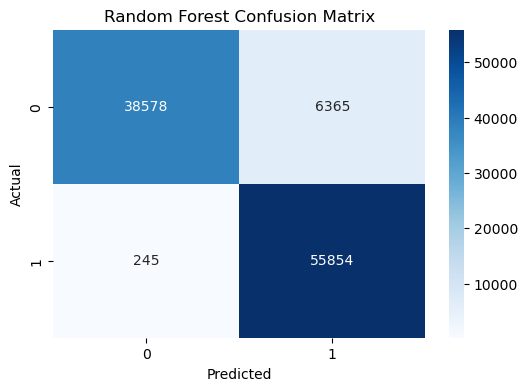

In [23]:
cm = confusion_matrix(
    y_test,
    rf_pred
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title(
    "Random Forest Confusion Matrix"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [24]:
importance = rf_model.feature_importances_

feat_imp = pd.DataFrame({

    "Feature": X.columns,

    "Importance": importance
})

In [25]:
feat_imp = feat_imp.sort_values(
    by="Importance",
    ascending=False
)

print(feat_imp.head(10))

                    Feature  Importance
9            Spend_Per_Call    0.207023
1             Support Calls    0.168061
3               Total Spend    0.139084
2             Payment Delay    0.134109
0                       Age    0.112331
6   Contract Length_Monthly    0.101511
4          Last Interaction    0.036643
8           Calls_Per_Delay    0.032514
5               Gender_Male    0.024536
10  Interaction_Delay_Ratio    0.021239


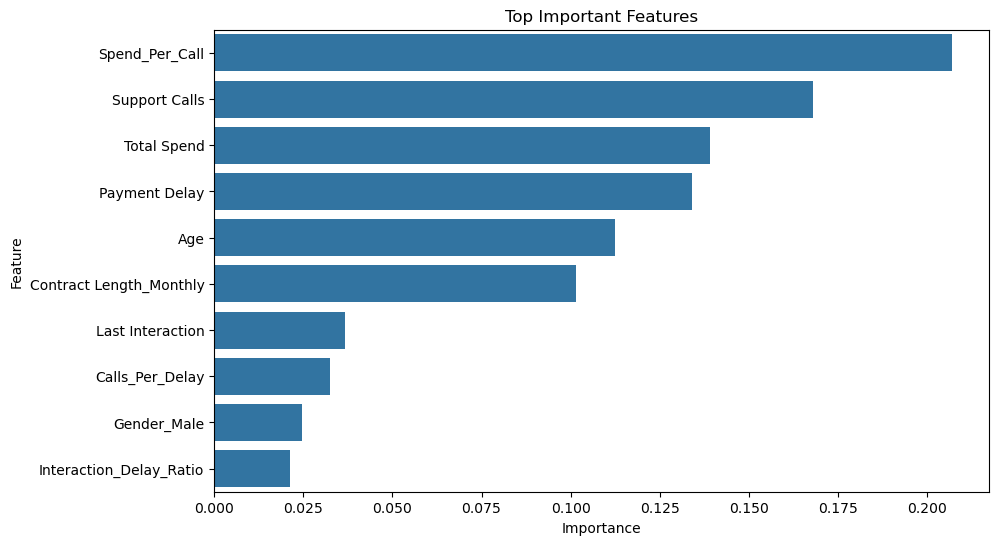

In [26]:
plt.figure(figsize=(10,6))

sns.barplot(

    x=feat_imp["Importance"][:10],

    y=feat_imp["Feature"][:10]
)

plt.title(
    "Top Important Features"
)

plt.show()

In [27]:
print("""

Final Best Model:
Random Forest Classifier

Final Accuracy:
93.45%

""")



Final Best Model:
Random Forest Classifier

Final Accuracy:
93.45%




In [28]:
results = {

    "Logistic Regression": 0.8484,

    "Decision Tree": 0.8770,

    "Extra Trees": 0.9274,

    "XGBoost": 0.9343,

    "CatBoost": 0.9345,

    "Random Forest": 0.9346
}

In [29]:
results_df = pd.DataFrame({

    "Model": results.keys(),

    "Accuracy": results.values()
})

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
)

results_df

,Model,Accuracy
5,Random Forest,0.9346
4,CatBoost,0.9345
3,XGBoost,0.9343
2,Extra Trees,0.9274
1,Decision Tree,0.8770
0,Logistic Regression,0.8484


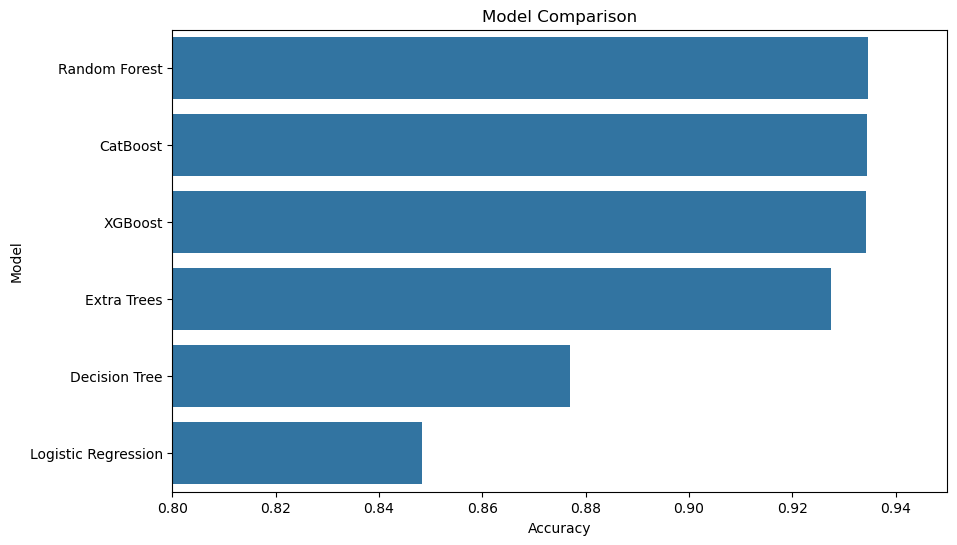

In [30]:
plt.figure(figsize=(10,6))

sns.barplot(

    x="Accuracy",

    y="Model",

    data=results_df
)

plt.title("Model Comparison")

plt.xlim(0.80, 0.95)

plt.show()